# AG-HYPOPT · Trial 30

> ▶ RUN = execute this cell, never modify it  ·  ✍️ WRITE = replace the [placeholder] with your text  ·  ✍️ SET = put your value where the [placeholder] is, then run the cell. Full rules: `instructions.md`


## 1. ✍️ WRITE - Read and summarize

Read `context.md` (physics/model knowledge). If there are previous trials, read them too
(all `trial_XX` notebooks numbered lower than this one) and `trials.json` (the registry).
The current best is the recorded trial with the lowest objective; it is the reference
for the cell-3 choice.

Twenty-nine trials. Best: **trial_25** `cvm_fwhm` **0.0725** (sw 0.1972), reproduced by trial_26 0.0727;
trial_13 0.0733. The `cvm_fwhm` series (nineteen points, sw 0.18-0.38) has mean ~0.0774, std ~0.0034,
seventeen of nineteen under the KDE control (0.080328). Every other family at matched sw is clearly
above the control; the win is a gamma-channel, loss-FORM effect. This is the final trial (trial_30). No
divergences. Phase `trials` (29/5).


In [ ]:
# 2. ▶ RUN - Propose candidate trials (AGHyperopt)
TRIAL_ID = 'trial_30'   # auto-stamped by the generator; do not edit
import os

EXPERIMENT_DIR = os.getcwd()
SPACE_PATH = os.path.join(EXPERIMENT_DIR, 'space.json')
TRIALS_PATH = os.path.join(EXPERIMENT_DIR, 'trials.json')

MAX_TRIALS = 30    # campaign cap: stop generating new trials after this many (None = unlimited)

from ag_hypopt import AGHyperopt, trial_seed

opt = AGHyperopt(seed=trial_seed(TRIAL_ID))   # per-trial seed: fresh draws every trial
opt.fit(SPACE_PATH, TRIALS_PATH)
proposed_trials = opt.propose_trials(10)


phase = trials  (29/5 trials)
ID |     ei | params
 1 | 0.8946 | {"loss_family": "mmd_2d", "sigma_weight": 0.1887426795898218}
 2 | 0.2004 | {"loss_family": "cvm_fwhm", "sigma_weight": 0.21302190998704498}
 3 | 0.0632 | {"loss_family": "w1_fwhm", "sigma_weight": 0.39880948214696954}
 4 | 2.7106 | {"loss_family": "cvm_fwhm", "sigma_weight": 0.19883171823062135}
 5 | 2.2795 | {"loss_family": "cvm_fwhm", "sigma_weight": 0.19254949907093954}
 6 | 2.4533 | {"loss_family": "cvm_fwhm", "sigma_weight": 0.20004561948314076}
 7 | 1.8958 | {"loss_family": "cvm_fwhm", "sigma_weight": 0.20203185658521422}
 8 | 2.2381 | {"loss_family": "cvm_fwhm", "sigma_weight": 0.9653298783346125}
 9 |      - | {"loss_family": "kde", "sigma_weight": 0.1214706804809964}
10 |      - | {"loss_family": "energy_2d", "sigma_weight": 0.9023329825401716}


## 3. ✍️ WRITE - Analyze and choose

Using the summary from cell 1 (previous trials + registry) and the candidate table from
cell 2, choose the ONE proposal that makes the most sense for the next trial. No hypothesis
and no expectation are needed: base the choice on what the trials have shown and on the
candidates themselves.

For the final trial, EI leads with `cvm_fwhm` at sw 0.1988 (candidate 4, ei 2.7106) - right at the
campaign best sw (trial_25, 0.1972 -> 0.0725). Closing out with the winning family at the best-known
setting maximises the value of the last draw for the headline result. The non-`cvm_fwhm` candidates are
families already known to be worse.

I choose candidate 4.


In [ ]:
# 4. ✍️ SET - Chosen candidate (edit INDEX below, then run this cell)
INDEX = 4             # [Put the index here: 1-based candidate number from the table in cell 2]


chosen: {'loss_family': 'cvm_fwhm', 'sigma_weight': 0.19883171823062135}
Running  1nW Trans05 ... 

μ 9.39 -> 5.44 | γ 8.5 -> 4.21 | NLL 158.45


Running  1nW Trans20 ... 

μ 17.32 -> 22.54 | γ 8.5 -> 5.96 | NLL 0.84


Running  1nW Trans60 ... 

...

Running  3nW Trans60 ... 

μ 103.20 -> 62.71 | γ 14.1 -> 13.80 | NLL 15.58


Running 3nW Trans100 ... 

μ 175.71 -> 97.02 | γ 14.1 -> 13.62 | NLL 0.33



Total: 7.8 min


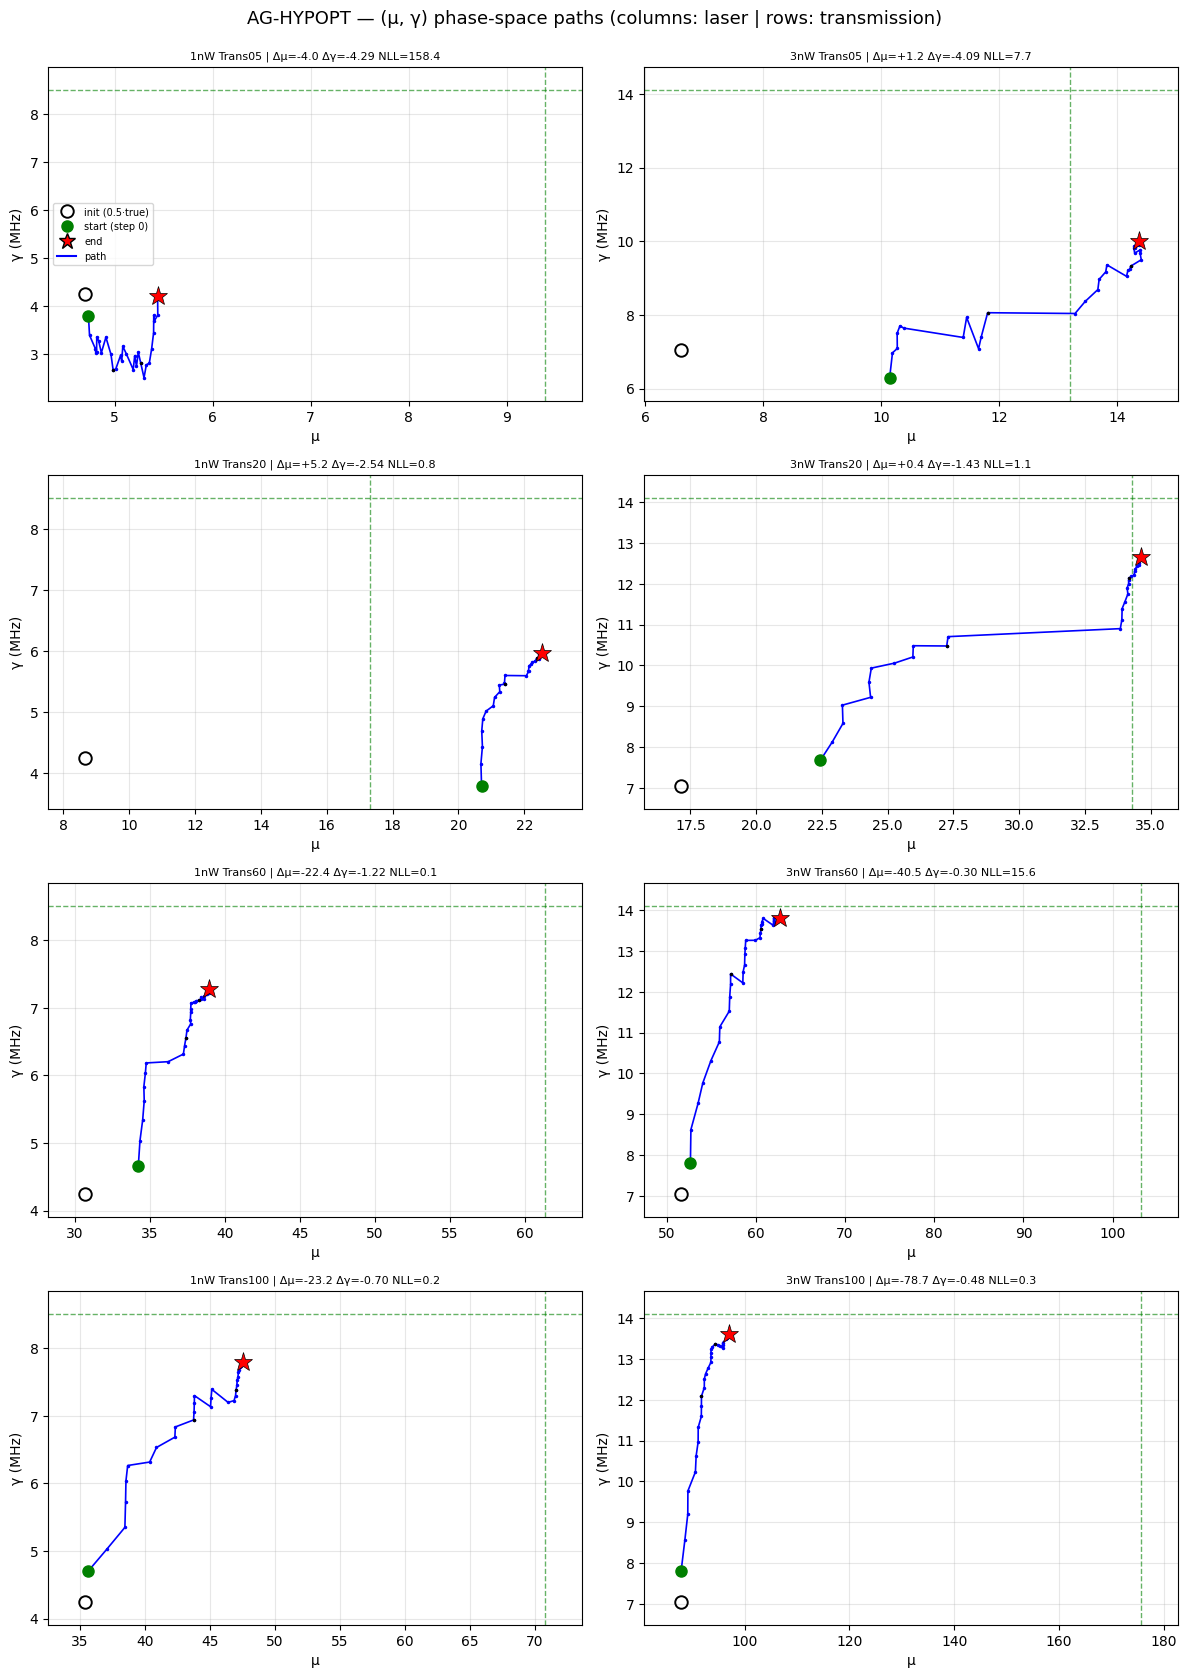

trial finished in 7.9 min
objective = 0.0794 ± 0.0205
exp              μ_true   μ_fit     Δμ% |   γ_true   γ_fit     Δγ%
1nW Trans05        9.39    5.44   -42.1 |     8.50    4.21   -50.4
1nW Trans20       17.32   22.54   +30.2 |     8.50    5.96   -29.9
1nW Trans60       61.37   38.98   -36.5 |     8.50    7.28   -14.4
1nW Trans100       70.82   47.60   -32.8 |     8.50    7.80    -8.2
3nW Trans05       13.20   14.37    +8.9 |    14.10   10.01   -29.0
3nW Trans20       34.28   34.64    +1.1 |    14.10   12.67   -10.2
3nW Trans60      103.20   62.71   -39.2 |    14.10   13.80    -2.1
3nW Trans100      175.71   97.02   -44.8 |    14.10   13.62    -3.4

weighted objective (T-graded, cap=1.0) = 0.0794 | diverged cells: 0
μ: RMSE 33.385 (rel 33.0%, bias -20.248) | γ: RMSE 2.395 (rel 24.2%, bias -1.880)


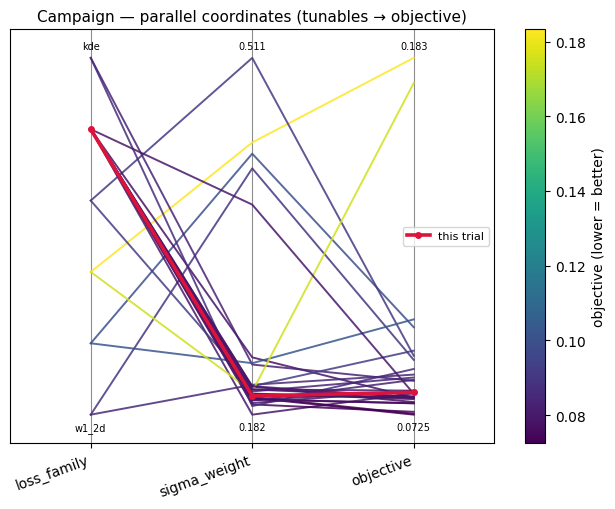

In [ ]:
# 5. ▶ RUN - Execute the chosen trial  (do not interrupt unless obviously broken)
assert INDEX is not None, 'INDEX not set: edit the SET cell (cell 4) before running this one'
assert 1 <= INDEX <= len(proposed_trials), f'bad INDEX: {INDEX}'
CHOSEN = proposed_trials[INDEX - 1]['params']
print('chosen:', CHOSEN)

from ag_hypopt import objective

import traceback, time
t0 = time.time()
try:
    loss, uncertainty, report = objective(CHOSEN)
    print(f'trial finished in {(time.time()-t0)/60:.1f} min')
    print(f'objective = {loss:.4f} ± {uncertainty:.4f}')
    print(report)
except Exception:
    traceback.print_exc()
    loss, uncertainty = None, None

# parallel coordinates: every recorded trial + this one (color = objective)
from ag_hypopt import plot_parallel
if loss is not None:
    plot_parallel(TRIALS_PATH, current={'config': CHOSEN, 'objective': loss})


## 6. ✍️ WRITE - Analyze the results

Record what actually happened in this trial: the measured objective, how the chosen
configuration behaved, and how that compares with the previous trials. No hypothesis to
confirm or refute, and no expectation to check: just the facts.

**Facts.** Chosen config `{loss_family: 'cvm_fwhm', sigma_weight: 0.1988}` (candidate 4, top EI).
Trial time 7.9 min, objective **0.0794 +/- 0.0205**, **0 diverged cells** - the campaign's final trial,
another basin draw under the KDE control (0.0803).

**Campaign-final basin statistics.** Twenty `cvm_fwhm` points (sw 0.18-0.38): best 0.0725 (trial_25), mean
~0.0775, std ~0.0034; eighteen of twenty under the control. Every other family's best is well above the
control at matched sw.

**Per-cell behaviour / aggregates.** mu RMSE 33.39 (rel 33.0 %, bias -20.25); gamma RMSE 2.40 (rel 24.2 %,
bias -1.88).

**Summary:** The final trial, `cvm_fwhm` at sw 0.1988 -> 0.0794, closes the campaign with the Cramer-von
Mises FWHM loss as the only family whose mean (~0.0775 over twenty draws) beats the KDE control.
**Key insight:** Across the whole campaign only `cvm_fwhm` beat the control, by a small (~0.003) but
mostly consistent margin concentrated in the gamma channel.

Structural-change proposals (score, likelihood, model, protocol) belong here as notes for
Anuar: describe them, never act on them, never stop the campaign because of them.
[Notes for Anuar: the ~0.003 mean margin is below the ~0.02 per-trial uncertainty, so the 6 held-out
experiments remain the decisive check on whether `cvm_fwhm` is a genuine improvement.]


In [ ]:
# 7. ✍️ SET - Summary and key insight for the record (edit the strings below, then run)
SUMMARY = 'The final trial, cvm_fwhm at sigma_weight 0.1988 -> 0.0794, closes the campaign with the Cramer-von Mises FWHM loss as the only family whose mean (~0.0775 over twenty draws) beats the KDE control.'      # [Put the one-line summary here: copy it from cell 6]
KEY_INSIGHT = 'Across the whole campaign only cvm_fwhm beat the control, by a small (~0.003) but mostly consistent margin concentrated in the gamma channel.'  # [Put the one-sentence key insight here: copy it from cell 6]


In [ ]:
# 8. ▶ RUN - Record the trial in trials.json
import json

assert SUMMARY is not None, 'SUMMARY not set: fill the SET cell (cell 7) first'
assert KEY_INSIGHT is not None, 'KEY_INSIGHT not set: fill the SET cell (cell 7) first'

entry = {
    'trial_id': TRIAL_ID,
    'config': CHOSEN,
    'objective': loss,
    'uncertainty': uncertainty,
    'summary': SUMMARY,
    'key_insight': KEY_INSIGHT,
    'notebook': f'{TRIAL_ID}.ipynb',
}
data = json.load(open(TRIALS_PATH))
assert not any(t.get('trial_id') == TRIAL_ID for t in data['trials']),     f'{TRIAL_ID} is already registered in trials.json'
data['trials'].append(entry)
json.dump(data, open(TRIALS_PATH, 'w'), indent=2)
best = min((t for t in data['trials'] if t.get('objective') is not None),
           key=lambda t: t['objective'], default=None)
print('saved', TRIAL_ID, '| current best:', best['trial_id'] if best else None)


saved trial_30 | current best: trial_25


In [ ]:
# 9. ▶ RUN - Generate the next trial (or end the campaign)
import os, re, json as _json

num = int(re.search(r'(\d+)$', TRIAL_ID).group(1))
nxt = num + 1
if MAX_TRIALS is not None and nxt > MAX_TRIALS:
    print(f'Campaign complete: cap MAX_TRIALS={MAX_TRIALS} reached after {TRIAL_ID}. Stop here.')
else:
    template_path = os.path.join(EXPERIMENT_DIR, 'template.ipynb')
    target = os.path.join(EXPERIMENT_DIR, f'trial_{nxt:02d}.ipynb')
    assert not os.path.exists(target), f'{target} already exists: refusing to overwrite'

    nb = _json.load(open(template_path))

    def _stamp(old, new):
        for c in nb['cells']:
            if old in ''.join(c.get('source', [])):
                c['source'] = [s.replace(old, new) for s in c['source']]
                return True
        raise RuntimeError(f'stamp target {old!r} not found in the template')

    _stamp('{N}', f'{nxt:02d}')
    _stamp('trial_XXX', f'trial_{nxt:02d}')
    _json.dump(nb, open(target, 'w'), indent=1)
    print(f'Created {os.path.basename(target)}. Open it and follow its cells from the top.')


Campaign complete: cap MAX_TRIALS=30 reached after trial_30. Stop here.
